**Justin Hovious**

**5/2/2026**

**Wave Energy Farm Power Prediction**

In [ ]:
# General Imports for data and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Importing libraries for metric validatiton and scoring
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
# Mounting google drive to access dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Dataset consists of X,Y coordinates for 49 Wave Energy Converters (formally called WECs or informally called buoys) set up at various positions and formations around the water energy farm in Perth Austrialia. Each WEC has a column showing the power generated at a given X,Y coordinate. Then, the target column shows the total power generated by all 49 WECs per row.

In [ ]:
# Creating Pandas dataframe from Large-scale Wave Energy Farm/WEC_Perth_49 dataset
data = pd.read_csv("/content/drive/MyDrive/Machine Learning/CSCI 460/Large-scale Wave Energy Farm/WEC_Perth_49.csv")
df = pd.DataFrame(data)

**1. Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
# Removing XY coordinate columns since they aren't useful for prediction
df = df.drop(columns=[col for col in df.columns if col.startswith(('X', 'Y'))])
print(df.shape)

(36043, 51)


In [ ]:
# Features and target
X = df.drop(columns=['Total_Power'])
y = df['Total_Power']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

"""
Creating a dictionary to store the results metrics for each model. This
will be used to compare results as the testing is conducted. A new dictionary
will be used at the end of the end of the notebook for a complete comparison
and plotting data.
"""
results = {}

In [ ]:
print(f"X Train shape: {X_train.shape}")
print(f"y Train shape: {y_train.shape}")
print(f"X Test shape: {X_test.shape}")
print(f"y Test shape: {y_test.shape}")

X Train shape: (28834, 50)
y Train shape: (28834,)
X Test shape: (7209, 50)
y Test shape: (7209,)


In [ ]:
# Instantiating a basic Linear Regression Model
lin_reg = LinearRegression()

# Training the model
lin_reg.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Making predictions and computing result metrics
y_pred = lin_reg.predict(X_test)

lin_mae = mean_absolute_error(y_test, y_pred)
lin_mse = mean_squared_error(y_test, y_pred)
lin_rmse = np.sqrt(lin_mse)
lin_r2 = r2_score(y_test, y_pred)

print("MAE:", lin_mae)
print("MSE:", lin_mse)
print("RMSE:", lin_rmse)
print("R2:", lin_r2)

results['linear_regression'] = {
    'MAE': lin_mae,
    'MSE': lin_mse,
    'RMSE': lin_rmse,
    'R2': lin_r2
}

MAE: 289.24799162963785
MSE: 181428.83652935983
RMSE: 425.9446402167303
R2: 0.9999876899690634


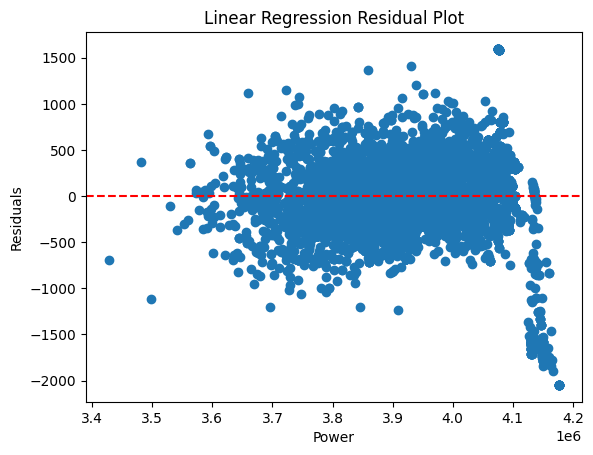

In [ ]:
residuals = (y_test - y_pred)

%matplotlib inline
plt.scatter(y_test, residuals)
plt.ylabel('Residuals')
plt.xlabel('Power')
plt.title('Linear Regression Residual Plot')
plt.axhline(0, color='red', linestyle='--')

**2. Ridge Regression**

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [ ]:
# Instantiating Standard Scaler
scaler = StandardScaler()

# Defining pipeline apply list of transformers
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# Hyperparamter tuning
param_grid = {
    'ridge__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'ridge__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sag', 'saga'],
    'ridge__fit_intercept': [True, False]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('ridge', Ridge())]),
             param_grid={'ridge__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100,
                                          1000],
                         'ridge__fit_intercept': [True, False],
                         'ridge__solver': ['auto', 'svd', 'cholesky', 'lsqr',
                                           'sag', 'saga']},
             scoring='neg_mean_squared_error')

In [ ]:
# Extracting best from each metric
best_ridge = grid.best_estimator_
best_params = grid.best_params_
best_score = grid.best_score_
best_mse = -grid.best_score_

print(f"Best Model: {best_ridge}\n")
print(f"Best Parameters: {best_params}\n")
print(f"Best Score: {best_score}\n")
print(f"Best MSE: {best_mse}\n")

Best Model: Pipeline(steps=[('scaler', StandardScaler()),
                ('ridge', Ridge(alpha=0.01, solver='sag'))])

Best Parameters: {'ridge__alpha': 0.01, 'ridge__fit_intercept': True, 'ridge__solver': 'sag'}

Best Score: -187412.73392829008

Best MSE: 187412.73392829008



In [ ]:
# Evaluating the best model
y_pred = best_ridge.predict(X_test)

ridge_mae = mean_absolute_error(y_test, y_pred)
ridge_mse = mean_squared_error(y_test, y_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, y_pred)

print("MAE:", ridge_mae)
print("MSE:", ridge_mse)
print("RMSE:", ridge_rmse)
print("R2:", ridge_r2)

# Storing results to dictionary
results['ridge_regression'] = {
    'MAE': ridge_mae,
    'MSE': ridge_mse,
    'RMSE': ridge_rmse,
    'R2': ridge_r2
}

MAE: 289.1328599265875
MSE: 181453.39758265694
RMSE: 425.9734705150744
R2: 0.9999876883025846


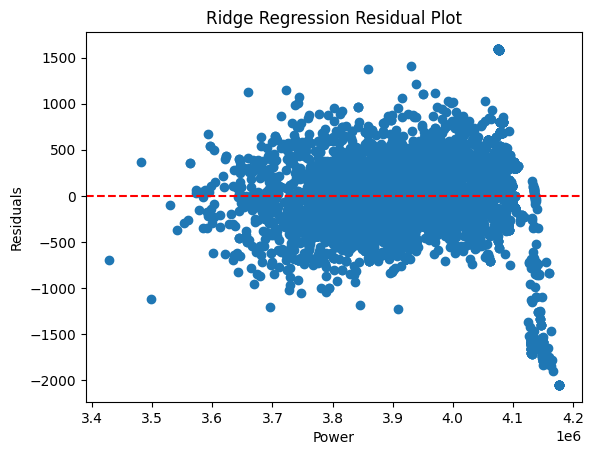

In [ ]:
residuals = (y_test - y_pred)

%matplotlib inline
plt.scatter(y_test, residuals)
plt.ylabel('Residuals')
plt.xlabel('Power')
plt.title('Ridge Regression Residual Plot')
plt.axhline(0, color='red', linestyle='--')

**3. Lasso**

In [ ]:
from sklearn.linear_model import Lasso

In [ ]:
# Defining pipeline apply list of transformers
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

# Hyperparamter tuning
param_grid = {
    'lasso__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10],
    'lasso__fit_intercept': [True, False],
    'lasso__selection': ['cyclic', 'random']
}

# Grid search
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('lasso', Lasso(max_iter=10000))]),
             param_grid={'lasso__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10],
                         'lasso__fit_intercept': [True, False],
                         'lasso__selection': ['cyclic', 'random']},
             scoring='neg_mean_squared_error')

In [ ]:
# Extracting best from each metric
best_lasso = grid.best_estimator_
best_params = grid.best_params_
best_score = grid.best_score_
best_mse = -grid.best_score_

print(f"Best Model: {best_lasso}\n")
print(f"Best Parameters: {best_params}\n")
print(f"Best Score: {best_score}\n")
print(f"Best MSE: {best_mse}\n")

Best Model: Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso', Lasso(alpha=0.1, max_iter=10000))])

Best Parameters: {'lasso__alpha': 0.1, 'lasso__fit_intercept': True, 'lasso__selection': 'cyclic'}

Best Score: -187438.54325530832

Best MSE: 187438.54325530832



In [ ]:
# Evaluating the best model
y_pred = best_lasso.predict(X_test)

lasso_mae = mean_absolute_error(y_test, y_pred)
lasso_mse = mean_squared_error(y_test, y_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, y_pred)

print("MAE:", lasso_mae)
print("MSE:", lasso_mse)
print("RMSE:", lasso_rmse)
print("R2:", lasso_r2)

# Storing results to dictionary
results['lasso'] = {
    'MAE': lasso_mae,
    'MSE': lasso_mse,
    'RMSE': lasso_rmse,
    'R2': lasso_r2
}

MAE: 289.1968644496227
MSE: 181507.33044216718
RMSE: 426.0367712324456
R2: 0.999987684643215


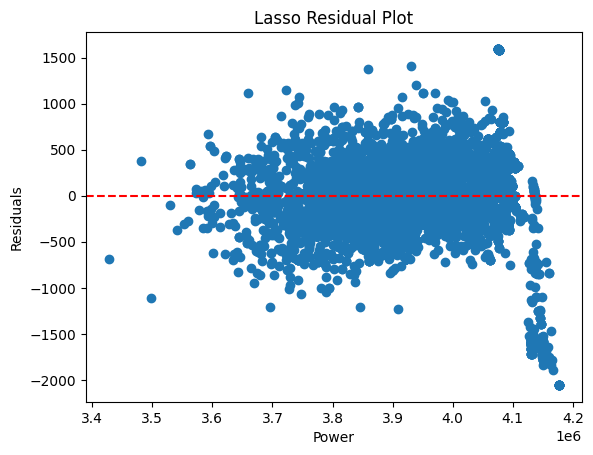

In [ ]:
residuals = (y_test - y_pred)

%matplotlib inline
plt.scatter(y_test, residuals)
plt.ylabel('Residuals')
plt.xlabel('Power')
plt.title('Lasso Residual Plot')
plt.axhline(0, color='red', linestyle='--')

**4. Random Forest Regressor**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Defining pipeline apply list of transformers
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor())
])

# Hyperparamter tuning
param_grid = {
    'rf__n_estimators': [100],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2']
}

# Grid search
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('rf', RandomForestRegressor())]),
             n_jobs=-1,
             param_grid={'rf__max_depth': [None, 10, 20],
                         'rf__max_features': ['sqrt', 'log2'],
                         'rf__min_samples_leaf': [1, 2, 4],
                         'rf__min_samples_split': [2, 5],
                         'rf__n_estimators': [100]},
             scoring='neg_mean_squared_error')

In [ ]:
# Extracting best from each metric
best_rf = grid.best_estimator_
best_params = grid.best_params_
best_score = grid.best_score_
best_mse = -grid.best_score_

print(f"Best Model: {best_rf}\n")
print(f"Best Parameters: {best_params}\n")
print(f"Best Score: {best_score}\n")
print(f"Best MSE: {best_mse}\n")

Best Model: Pipeline(steps=[('scaler', StandardScaler()),
                ('rf', RandomForestRegressor(max_features='sqrt'))])

Best Parameters: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}

Best Score: -139681474.91316548

Best MSE: 139681474.91316548



In [ ]:
# Evaluating the best model
y_pred = best_rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred)
rf_mse = mean_squared_error(y_test, y_pred)
rf_rmse = np.sqrt(lasso_mse)
rf_r2 = r2_score(y_test, y_pred)

print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

# Storing results to dictionary
results['random_forest'] = {
    'MAE': rf_mae,
    'MSE': rf_mse,
    'RMSE': rf_rmse,
    'R2': rf_r2
}

MAE: 3318.2805869821445
MSE: 97264147.46218903
RMSE: 426.0367712324456
R2: 0.9934005823595584


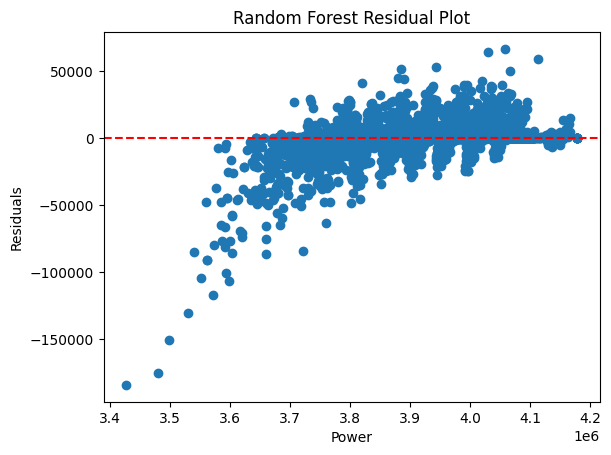

In [ ]:
residuals = y_test - y_pred

plt.scatter(y_test, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Power")
plt.ylabel("Residuals")
plt.title("Random Forest Residual Plot")
plt.show()

**5. Extra Trees Regressor**

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor

In [ ]:
# Defining pipeline apply list of transformers
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('et', ExtraTreesRegressor())
])

# Hyperparamter tuning
param_grid = {
    'et__n_estimators': [100],
    'et__max_depth': [None, 10, 20],
    'et__min_samples_split': [2, 5],
    'et__min_samples_leaf': [1, 2, 4],
    'et__max_features':['sqrt']
}

# Grid search
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('et', ExtraTreesRegressor())]),
             n_jobs=-1,
             param_grid={'et__max_depth': [None, 10, 20],
                         'et__max_features': ['sqrt'],
                         'et__min_samples_leaf': [1, 2, 4],
                         'et__min_samples_split': [2, 5],
                         'et__n_estimators': [100]},
             scoring='neg_mean_squared_error')

In [ ]:
# Extracting best from each metric
best_et = grid.best_estimator_
best_params = grid.best_params_
best_score = grid.best_score_
best_mse = -grid.best_score_

print(f"Best Model: {best_et}\n")
print(f"Best Parameters: {best_params}\n")
print(f"Best Score: {best_score}\n")
print(f"Best MSE: {best_mse}\n")

Best Model: Pipeline(steps=[('scaler', StandardScaler()),
                ('et', ExtraTreesRegressor(max_depth=20, max_features='sqrt'))])

Best Parameters: {'et__max_depth': 20, 'et__max_features': 'sqrt', 'et__min_samples_leaf': 1, 'et__min_samples_split': 2, 'et__n_estimators': 100}

Best Score: -181057431.48903856

Best MSE: 181057431.48903856



In [ ]:
# Evaluating the best model
y_pred = best_et.predict(X_test)

et_mae = mean_absolute_error(y_test, y_pred)
et_mse = mean_squared_error(y_test, y_pred)
et_rmse = np.sqrt(et_mse)
et_r2 = r2_score(y_test, y_pred)

print("MAE:", et_mae)
print("MSE:", et_mse)
print("RMSE:", et_rmse)
print("R2:", et_r2)

# Storing results to dictionary
results['extra_trees'] = {
    'MAE': et_mae,
    'MSE': et_mse,
    'RMSE': et_rmse,
    'R2': et_r2
}

MAE: 4263.326468048257
MSE: 130759262.58706819
RMSE: 11435.00164350964
R2: 0.9911279232205916


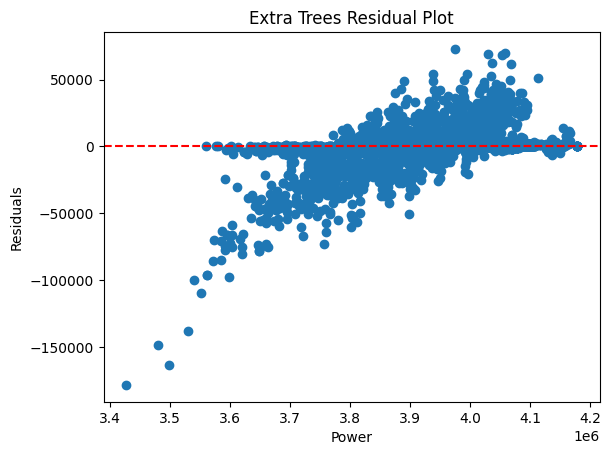

In [ ]:
residuals = y_test - y_pred

plt.scatter(y_test, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Power")
plt.ylabel("Residuals")
plt.title("Extra Trees Residual Plot")
plt.show()

**6. XGB Regressor**

In [ ]:
from xgboost import XGBRegressor

In [ ]:
# Defining pipeline to apply list of transformers
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor(
        objective='reg:squarederror',
        tree_method='hist',
        eval_metric='rmse'
    ))
])

# Hyperparamter tuning
param_grid = {
    'xgb__n_estimators': [100],
    'xgb__max_depth': [None, 5, 10],
    'xgb__learning_rate': [0.01, 0.1, 0.3],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

# Grid search
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('xgb',
                                        XGBRegressor(base_score=None,
                                                     booster=None,
                                                     callbacks=None,
                                                     colsample_bylevel=None,
                                                     colsample_bynode=None,
                                                     colsample_bytree=None,
                                                     device=None,
                                                     early_stopping_rounds=None,
                                                     enable_categorical=False,
                                                     eval_metric='rmse',
                                                     feature_types=None,
                                                     feature_weights=None,
                                                     gamma=None,
                                                     grow_policy=N...
                                                     max_leaves=None,
                                                     min_child_weight=None,
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=None,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'xgb__colsample_bytree': [0.8, 1.0],
                         'xgb__learning_rate': [0.01, 0.1, 0.3],
                         'xgb__max_depth': [None, 5, 10],
                         'xgb__n_estimators': [100],
                         'xgb__subsample': [0.8, 1.0]},
             scoring='neg_mean_squared_error')

In [ ]:
# Extracting best from each metric
best_xgb = grid.best_estimator_
best_params = grid.best_params_
best_score = grid.best_score_
best_mse = -grid.best_score_

print(f"Best Model: {best_xgb}\n")
print(f"Best Parameters: {best_params}\n")
print(f"Best Score: {best_score}\n")
print(f"Best MSE: {best_mse}\n")

Best Model: Pipeline(steps=[('scaler', StandardScaler()),
                ('xgb',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=1.0, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric='rmse',
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=10, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              mo

In [ ]:
# Evaluating the best model
y_pred = best_xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test, y_pred)
xgb_mse = mean_squared_error(y_test, y_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, y_pred)

print("MAE:", xgb_mae)
print("MSE:", xgb_mse)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)

# Storing results to dictionary
results['xgboost'] = {
    'MAE': xgb_mae,
    'MSE': xgb_mse,
    'RMSE': xgb_rmse,
    'R2': xgb_r2
}

MAE: 2593.545068664168
MSE: 33234961.97829927
RMSE: 5764.977188012045
R2: 0.9977449923730195


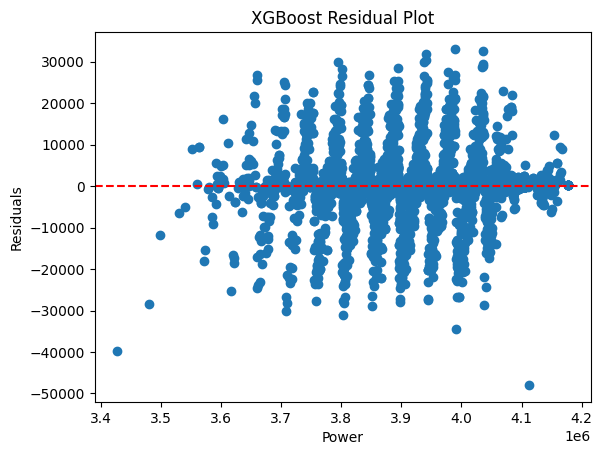

In [ ]:
residuals = y_test - y_pred

plt.scatter(y_test, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Power")
plt.ylabel("Residuals")
plt.title("XGBoost Residual Plot")
plt.show()

**Evaluating results and comparing each model**

In [ ]:
df_results = pd.DataFrame(results).T
df_results

,MAE,MSE,RMSE,R2
linear_regression,289.247992,1.814288e+05,425.944640,0.999988
ridge_regression,289.132860,1.814534e+05,425.973471,0.999988
lasso,289.196864,1.815073e+05,426.036771,0.999988
random_forest,3318.280587,9.726415e+07,426.036771,0.993401
extra_trees,4263.326468,1.307593e+08,11435.001644,0.991128
xgboost,2593.545069,3.323496e+07,5764.977188,0.997745


In [ ]:
# Gathering the best models from each test for comparison and versus testing
models = {
    'Linear Regression': lin_reg,
    'Ridge': best_ridge,
    'Lasso': best_lasso,
    'Random Forest': best_rf,
    'Extra Trees': best_et,
    'XGBoost': best_xgb
}

In [ ]:
# Creating a more detailed dictionary to use for model comparison and plots.
test_results = {}

# Train predictions
for name, model in models.items():
  y_train_pred = model.predict(X_train)
  train_mae = mean_absolute_error(y_train, y_train_pred)
  train_mse = mean_squared_error(y_train, y_train_pred)
  train_rmse = np.sqrt(train_mse)
  train_r2 = r2_score(y_train, y_train_pred)

  # Test predictions
  y_test_pred = model.predict(X_test)
  test_mae = mean_absolute_error(y_test, y_test_pred)
  test_mse = mean_squared_error(y_test, y_test_pred)
  test_rmse = np.sqrt(test_mse)
  test_r2 = r2_score(y_test, y_test_pred)

  test_results[name] = {
      'Train_MAE': train_mae,
      'Train_MSE': train_mse,
      'Train_RMSE': train_rmse,
      'Train_R2': train_r2,
      'Test_MAE': test_mae,
      'Test_MSE': test_mse,
      'Test_RMSE': test_rmse,
      'Test_R2': test_r2
  }

  df_test_results = pd.DataFrame(test_results).T

**Data Gathering**

The below section is just providing visualizations showing plots and tables for easier analysis on the performance of the models and to identify the best model for the task.

In [ ]:
df_test_results

,Train_MAE,Train_MSE,Train_RMSE,Train_R2,Test_MAE,Test_MSE,Test_RMSE,Test_R2
Linear Regression,292.961974,1.868844e+05,432.301299,0.999988,289.247992,1.814288e+05,425.944640,0.999988
Ridge,292.827041,1.868898e+05,432.307503,0.999988,289.132860,1.814534e+05,425.973471,0.999988
Lasso,292.881144,1.869055e+05,432.325697,0.999988,289.196864,1.815073e+05,426.036771,0.999988
Random Forest,1373.964147,1.704765e+07,4128.880110,0.998872,3318.280587,9.726415e+07,9862.258740,0.993401
Extra Trees,1006.114910,2.757891e+06,1660.689922,0.999817,4263.326468,1.307593e+08,11435.001644,0.991128
XGBoost,828.290924,2.002686e+06,1415.162991,0.999867,2593.545069,3.323496e+07,5764.977188,0.997745


In [ ]:
df_test_results.style.format({
    'Train_MAE': "{:.2f}",
    'Train_MSE': "{:.2f}",
    'Train_RMSE': "{:.2f}",
    'Test_MAE': "{:.2f}",
    'Test_MSE': "{:.2f}",
    'Test_RMSE': "{:.2f}",
    'Train_R2': "{:.6f}",
    'Test_R2': "{:.6f}"
})

,Train_MAE,Train_MSE,Train_RMSE,Train_R2,Test_MAE,Test_MSE,Test_RMSE,Test_R2
Linear Regression,292.96,186884.41,432.30,0.999988,289.25,181428.84,425.94,0.999988
Ridge,292.83,186889.78,432.31,0.999988,289.13,181453.40,425.97,0.999988
Lasso,292.88,186905.51,432.33,0.999988,289.20,181507.33,426.04,0.999988
Random Forest,1373.96,17047650.96,4128.88,0.998872,3318.28,97264147.46,9862.26,0.993401
Extra Trees,1006.11,2757891.02,1660.69,0.999817,4263.33,130759262.59,11435.00,0.991128
XGBoost,828.29,2002686.29,1415.16,0.999867,2593.55,33234961.98,5764.98,0.997745


In [ ]:
df_ranked = df_test_results.copy()
df_ranked['Rank'] = df_ranked['Test_RMSE'].rank(method='dense')
df_ranked.sort_values('Rank')

df_ranked.style.format({
    'Train_MAE': "{:.2f}",
    'Train_MSE': "{:.2f}",
    'Train_RMSE': "{:.2f}",
    'Test_MAE': "{:.2f}",
    'Test_MSE': "{:.2f}",
    'Test_RMSE': "{:.2f}",
    'Train_R2': "{:.6f}",
    'Test_R2': "{:.6f}",
    'Rank': "{:.0f}"
})

,Train_MAE,Train_MSE,Train_RMSE,Train_R2,Test_MAE,Test_MSE,Test_RMSE,Test_R2,Rank
Linear Regression,292.96,186884.41,432.30,0.999988,289.25,181428.84,425.94,0.999988,1
Ridge,292.83,186889.78,432.31,0.999988,289.13,181453.40,425.97,0.999988,2
Lasso,292.88,186905.51,432.33,0.999988,289.20,181507.33,426.04,0.999988,3
Random Forest,1373.96,17047650.96,4128.88,0.998872,3318.28,97264147.46,9862.26,0.993401,5
Extra Trees,1006.11,2757891.02,1660.69,0.999817,4263.33,130759262.59,11435.00,0.991128,6
XGBoost,828.29,2002686.29,1415.16,0.999867,2593.55,33234961.98,5764.98,0.997745,4


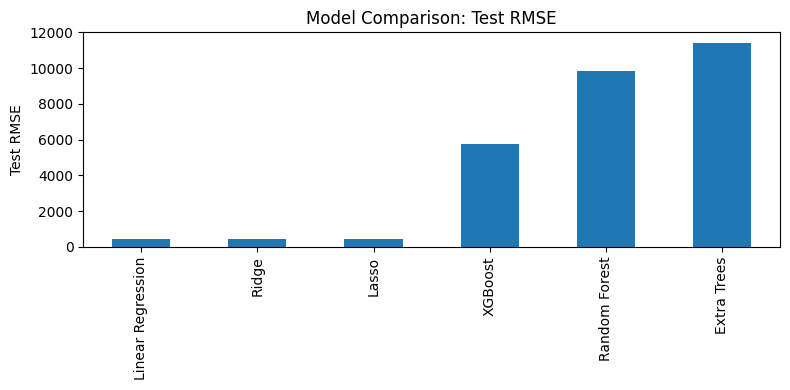

In [ ]:
#Plotting results and comparing model performance

# Bar chart for Test RMSE
plt.figure(figsize=(8, 4))
df_test_results['Test_RMSE'].sort_values().plot(kind='bar')
plt.ylabel('Test RMSE')
plt.title('Model Comparison: Test RMSE')
plt.tight_layout()
plt.savefig("rmse_bar.png", dpi=600, bbox_inches="tight")
plt.show()


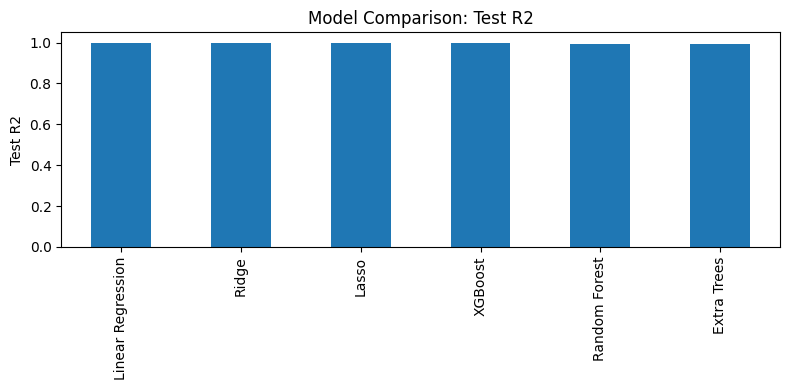

In [ ]:
# Bar chart for Test R2 score
plt.figure(figsize=(8, 4))
df_test_results['Test_R2'].sort_values(ascending=False).plot(kind='bar')
plt.ylabel('Test R2')
plt.title('Model Comparison: Test R2')
plt.tight_layout()
plt.savefig("R2_bar.png", dpi=600, bbox_inches="tight")
plt.show()

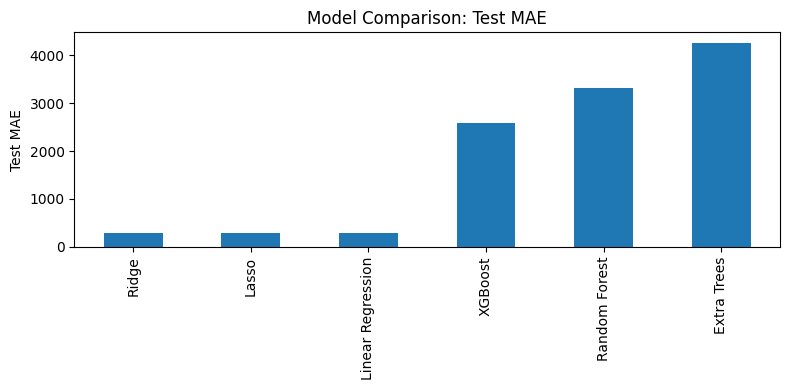

In [ ]:
# Bar chart for Test MAE
plt.figure(figsize=(8, 4))
df_test_results['Test_MAE'].sort_values().plot(kind='bar')
plt.ylabel('Test MAE')
plt.title('Model Comparison: Test MAE')
plt.tight_layout()
plt.savefig("mae_bar.png", dpi=600, bbox_inches="tight")
plt.show()

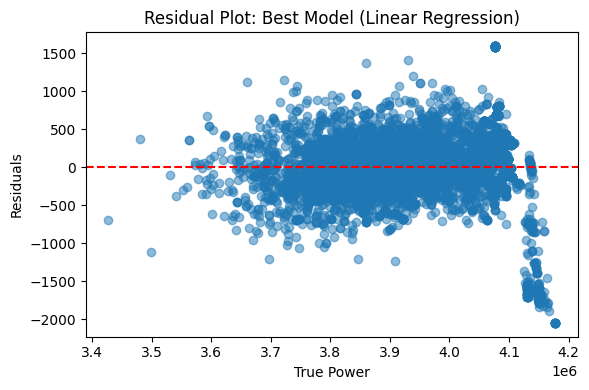

In [ ]:
y_test_pred_best = lin_reg.predict(X_test)
residuals = y_test - y_test_pred_best

plt.figure(figsize=(6, 4))
plt.scatter(y_test, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('True Power')
plt.ylabel('Residuals')
plt.title('Residual Plot: Best Model (Linear Regression)')
plt.tight_layout()
plt.savefig("lin_residuals_bar.png", dpi=600, bbox_inches="tight")
plt.show()